In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display
import copy
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

## 1. Generación aleatoria - archivo de datos
Reglas (ingreso lognormal, fraudes de madrugada/lejos/montos altos, ruido y desbalance 8 %).

In [ ]:
COLUMNAS = ["monto_pesos", "hora_dia", "distancia_residencia_km", "ingreso_mensual"]

def generar_datos(n=3000, tasa_fraude=0.08, semilla=42, ruta="transacciones.csv"):
    """
    Genera transacciones sinteticas con un comportamiento 'realista':

    - Ingreso mensual: lognormal, centrado en ~3 millones COP (minimo 1.4 M).
    - Transaccion legitima: monto es una fraccion pequena del ingreso, ocurre
      sobre todo de dia, y cerca de la residencia.
    - Fraude: monto mayor respecto al ingreso, mas frecuente de madrugada y
      lejos de la residencia.
    - Ruido (para que no sea trivial):
        * 12 % de los fraudes 'se parecen' a una transaccion normal
        * 1.5 % de las legitimas tienen rasgos sospechosos (viaje, compra grande)
    - Desbalance: ~8 % de fraudes (en la vida real suele ser incluso menor).
    """
    rng = np.random.default_rng(semilla)
    es_fraude = rng.random(n) < tasa_fraude

    ingreso = np.clip(rng.lognormal(mean=math.log(3_000_000), sigma=0.55, size=n),
                      1_400_000, 25_000_000)

    monto = np.empty(n)
    hora = np.empty(n)
    dist = np.empty(n)

    # --- legitimas
    L = ~es_fraude
    nL = L.sum()
    monto[L] = ingreso[L] * rng.lognormal(math.log(0.03), 0.9, nL)
    # horas: mezcla centrada a medio dia y en la tarde-noche
    hora[L] = np.where(rng.random(nL) < 0.6,
                       rng.normal(13, 3.5, nL), rng.normal(19, 2.5, nL)) % 24
    dist[L] = rng.lognormal(math.log(4), 0.9, nL)

    # --- fraudes
    F = es_fraude
    nF = F.sum()
    monto[F] = ingreso[F] * rng.lognormal(math.log(0.30), 0.8, nF)
    hora[F] = np.where(rng.random(nF) < 0.7,
                       rng.normal(2.5, 2.0, nF), rng.uniform(0, 24, nF)) % 24
    dist[F] = rng.lognormal(math.log(60), 0.9, nF)

    # --- ruido: fraudes que parecen normales
    idxF = np.where(F)[0]
    camuflados = rng.choice(idxF, size=int(0.12 * len(idxF)), replace=False)
    monto[camuflados] = ingreso[camuflados] * rng.lognormal(math.log(0.03), 0.6, len(camuflados))
    hora[camuflados] = rng.normal(14, 3, len(camuflados)) % 24
    dist[camuflados] = rng.lognormal(math.log(5), 0.6, len(camuflados))

    # --- ruido: legitimas con rasgos sospechosos (viaje, compra grande)
    idxL = np.where(L)[0]
    raras = rng.choice(idxL, size=int(0.015 * len(idxL)), replace=False)
    monto[raras] = ingreso[raras] * rng.lognormal(math.log(0.25), 0.5, len(raras))
    dist[raras] = rng.lognormal(math.log(40), 0.6, len(raras))

    df = pd.DataFrame({
        "monto_pesos": np.round(monto, -2).astype(int),   # redondeo a centenas de pesos
        "hora_dia": np.round(hora, 2),
        "distancia_residencia_km": np.round(dist, 1),
        "ingreso_mensual": np.round(ingreso, -3).astype(int),
        "fraude": np.where(es_fraude, "si", "no"),
    })
    df.to_csv(ruta, index=False)
    return df

## 2. Conjuntos de funciones y terminales  (pasos 2 y 3 del documento)

In [ ]:
def _div(a, b):
    """Division protegida: mantiene la propiedad de CLAUSURA."""
    return np.where(np.abs(b) > 1e-6, a / np.where(np.abs(b) > 1e-6, b, 1.0), 1.0)


FUNCIONES = {                      # nombre: (aridad, funcion, simbolo infijo o None)
    "add": (2, np.add, "+"),
    "sub": (2, np.subtract, "-"),
    "mul": (2, np.multiply, "*"),
    "div": (2, _div, "/"),
    "max": (2, np.maximum, None),
    "min": (2, np.minimum, None),
    "sin": (1, np.sin, None),
    "cos": (1, np.cos, None),
}
NOMBRES_FUNC = list(FUNCIONES)
TERMINALES = ["x0", "x1", "x2", "x3"]   # monto, hora, distancia, ingreso
ALIAS = {"x0": "monto", "x1": "hora", "x2": "distancia", "x3": "ingreso"}


def preparar_variables(df, escalas=None):
    """
    Escala las variables para que la PG trabaje con numeros de magnitud similar:
      x0 = monto / media_monto
      x1 = hora * 2*pi / 24   (angulo: asi sin/cos pueden representar 'madrugada')
      x2 = distancia / media_distancia
      x3 = ingreso / media_ingreso
    Devuelve matriz X (n,4) y las escalas usadas (para reutilizarlas en validacion/prueba).
    """
    if escalas is None:
        escalas = {
            "monto": df["monto_pesos"].mean(),
            "dist": df["distancia_residencia_km"].mean(),
            "ingreso": df["ingreso_mensual"].mean(),
        }
    X = np.column_stack([
        df["monto_pesos"] / escalas["monto"],
        df["hora_dia"] * 2 * np.pi / 24,
        df["distancia_residencia_km"] / escalas["dist"],
        df["ingreso_mensual"] / escalas["ingreso"],
    ])
    return X, escalas

## 3. Arboles: generacion, conteo, acceso por preorden, evaluacion

In [ ]:
def terminal_aleatorio(rng):
    if rng.random() < 0.7:
        return rng.choice(TERMINALES)
    return round(rng.uniform(-2, 2), 3)          # constante efimera


def generar_arbol(rng, prof_max, metodo="grow"):
    """Metodos 'full' y 'grow' (se combinan: ramped half-and-half)."""
    if prof_max == 0 or (metodo == "grow" and rng.random() < 0.3):
        return terminal_aleatorio(rng)
    f = rng.choice(NOMBRES_FUNC)
    aridad = FUNCIONES[f][0]
    return [f] + [generar_arbol(rng, prof_max - 1, metodo) for _ in range(aridad)]


def cuenta_nodos(t):
    """Cuenta_Nodos del documento."""
    if not isinstance(t, list):
        return 1
    return 1 + sum(cuenta_nodos(h) for h in t[1:])


def profundidad(t):
    if not isinstance(t, list):
        return 1
    return 1 + max(profundidad(h) for h in t[1:])


def obtener_subarbol(t, idx):
    """Devuelve el subarbol en la posicion idx (preorden, 0 = raiz)."""
    if idx == 0:
        return t
    idx -= 1
    for h in t[1:]:
        n = cuenta_nodos(h)
        if idx < n:
            return obtener_subarbol(h, idx)
        idx -= n
    raise IndexError


def reemplazar_subarbol(t, idx, nuevo):
    """Devuelve una COPIA de t con el nodo idx reemplazado por 'nuevo'."""
    if idx == 0:
        return copy.deepcopy(nuevo)
    resultado = [t[0]]
    idx -= 1
    for h in t[1:]:
        n = cuenta_nodos(h)
        if 0 <= idx < n:
            resultado.append(reemplazar_subarbol(h, idx, nuevo))
        else:
            resultado.append(h)
        idx -= n
    return resultado


def evaluar(t, X):
    """Ejecuta el arbol-programa sobre todas las filas de X (vectorizado)."""
    if not isinstance(t, list):
        if isinstance(t, str):
            return X[:, int(t[1])]
        return np.full(X.shape[0], float(t))
    aridad, fn, _ = FUNCIONES[t[0]]
    args = [evaluar(h, X) for h in t[1:]]
    with np.errstate(all="ignore"):
        r = fn(*args)
    return np.clip(np.nan_to_num(r, nan=0.0, posinf=1e6, neginf=-1e6), -1e6, 1e6)


def a_texto(t):
    """Expresion legible (infija) del arbol."""
    if not isinstance(t, list):
        return ALIAS.get(t, str(t)) if isinstance(t, str) else f"{t:g}"
    f = t[0]
    simbolo = FUNCIONES[f][2]
    if simbolo:
        return f"({a_texto(t[1])} {simbolo} {a_texto(t[2])})"
    return f"{f}(" + ", ".join(a_texto(h) for h in t[1:]) + ")"

## 4. Aptitud   f_apt = 1 / (0.1 + error)

In [ ]:
PENALIZACION_TAMANO = 0.0005   # presion parsimonia: evita arboles gigantes


def predecir(t, X):
    return evaluar(t, X) > 0.0          # salida > 0  ->  fraude


def error_balanceado(t, X, y):
    """
    Promedio de la tasa de falsos negativos y de falsos positivos.
    Con datos desbalanceados (8 % fraude) la exactitud simple engana: un
    modelo que siempre diga 'no fraude' tendria 92 % de acierto.
    """
    pred = predecir(t, X)
    fn = np.mean(~pred[y]) if y.any() else 0.0
    fp = np.mean(pred[~y]) if (~y).any() else 0.0
    return 0.5 * (fn + fp)


def aptitud(t, X, y):
    err = error_balanceado(t, X, y) + PENALIZACION_TAMANO * cuenta_nodos(t)
    return 1.0 / (0.1 + err)

## 5. operadores geneticos

In [ ]:
def torneo(pob, fits, k, rng):
    candidatos = rng.sample(range(len(pob)), k)
    return pob[max(candidatos, key=lambda i: fits[i])]


def cruce(p1, p2, rng, prof_limite):
    """Intercambio de subarboles en puntos de cruce escogidos al azar (preorden)."""
    c1 = rng.randrange(cuenta_nodos(p1))
    c2 = rng.randrange(cuenta_nodos(p2))
    s1, s2 = obtener_subarbol(p1, c1), obtener_subarbol(p2, c2)
    h1 = reemplazar_subarbol(p1, c1, s2)
    h2 = reemplazar_subarbol(p2, c2, s1)
    # el documento advierte que los arboles crecen en profundidad: se limita
    if profundidad(h1) > prof_limite:
        h1 = copy.deepcopy(p1)
    if profundidad(h2) > prof_limite:
        h2 = copy.deepcopy(p2)
    return h1, h2


def mutacion(t, rng, prof_limite):
    """Mutacion de subarbol: reemplaza un nodo por un subarbol aleatorio pequeno."""
    c = rng.randrange(cuenta_nodos(t))
    nuevo = generar_arbol(rng, 2, "grow")
    h = reemplazar_subarbol(t, c, nuevo)
    return h if profundidad(h) <= prof_limite else copy.deepcopy(t)

## 6. metricas

In [ ]:
def metricas(t, X, y):
    pred = predecir(t, X)
    tp = int(np.sum(pred & y))
    tn = int(np.sum(~pred & ~y))
    fp = int(np.sum(pred & ~y))
    fn = int(np.sum(~pred & y))
    exactitud = (tp + tn) / len(y)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return dict(tp=tp, tn=tn, fp=fp, fn=fn, exactitud=exactitud,
                precision=precision, recall=recall, f1=f1)


def imprimir_metricas(nombre, m):
    print(f"\n--- {nombre} ---")
    print(f"  Matriz de confusion:  VP={m['tp']}  FN={m['fn']}  FP={m['fp']}  VN={m['tn']}")
    print(f"  Exactitud={m['exactitud']:.3f}  Precision={m['precision']:.3f}  "
          f"Recall={m['recall']:.3f}  F1={m['f1']:.3f}")

## 7. ciclo evolutivo

In [ ]:
def evolucionar(Xtr, ytr, Xva, yva, tam_pob=200, generaciones=100, p_cruce=0.7,
                p_mut=0.1, k_torneo=3, n_elite=2, prof_ini=4, prof_max=8,
                semilla=0, verbose=True):
    rng = random.Random(semilla)

    # Generacion 0: poblacion inicial aleatoria (ramped half-and-half)
    pob = []
    for i in range(tam_pob):
        metodo = "full" if i % 2 == 0 else "grow"
        pob.append(generar_arbol(rng, 2 + i % (prof_ini - 1), metodo))

    historia = []
    salon_fama = []        # mejor individuo de cada generacion (hall of fame)

    for g in range(generaciones + 1):
        fits = [aptitud(t, Xtr, ytr) for t in pob]
        orden = sorted(range(tam_pob), key=lambda i: fits[i], reverse=True)
        mejor = pob[orden[0]]
        historia.append(fits[orden[0]])
        salon_fama.append(copy.deepcopy(mejor))

        if verbose and (g % 10 == 0 or g == generaciones):
            m = metricas(mejor, Xva, yva)
            print(f"Gen {g:3d} | apt. entren. = {fits[orden[0]]:.4f} | "
                  f"nodos = {cuenta_nodos(mejor):3d} | F1 valid. = {m['f1']:.3f}")

        if g == generaciones:
            break

        # Nueva poblacion: elitismo + reproduccion / cruce / mutacion
        nueva = [copy.deepcopy(pob[i]) for i in orden[:n_elite]]
        while len(nueva) < tam_pob:
            r = rng.random()
            if r < p_cruce:
                h1, h2 = cruce(torneo(pob, fits, k_torneo, rng),
                               torneo(pob, fits, k_torneo, rng), rng, prof_max)
                nueva.extend([h1, h2])
            elif r < p_cruce + p_mut:
                nueva.append(mutacion(torneo(pob, fits, k_torneo, rng), rng, prof_max))
            else:                                   # reproduccion (copia)
                nueva.append(copy.deepcopy(torneo(pob, fits, k_torneo, rng)))
        pob = nueva[:tam_pob]

    # Resultado: de los mejores de cada generacion, el que mejor generaliza en VALIDACION
    # (desempate: arbol mas pequeno)
    def clave(t):
        return (error_balanceado(t, Xva, yva), cuenta_nodos(t))
    mejor_final = min(salon_fama, key=clave)
    return mejor_final, historia

## 8. Ejecución: datos → evolución → resultados

Archivo 'transacciones.csv' generado con 3000 transacciones.
Fraudes: 227 (7.6%)


,monto_pesos,hora_dia,distancia_residencia_km,ingreso_mensual,fraude
0,158000,18.52,3.1,5364000,no
1,14300,14.94,5.4,1980000,no
2,14800,10.04,1.1,1400000,no
3,15300,21.06,6.6,1400000,no
4,391300,19.15,1.1,6557000,no
5,90000,13.93,12.8,2406000,no
6,103200,20.49,6.4,1985000,no
7,42400,9.92,22.4,7404000,no
8,47500,15.44,7.3,6016000,no
9,165700,11.20,3.0,3041000,no


,monto_pesos,hora_dia,distancia_residencia_km,ingreso_mensual
count,3000.0,3000.0,3000.0,3000.0
mean,285090.6,14.8,11.9,3540535.3
std,827154.9,5.0,28.8,2085644.6
min,3800.0,0.0,0.1,1400000.0
25%,48500.0,11.7,2.4,2077000.0
50%,104150.0,15.3,4.7,3028500.0
75%,228600.0,18.5,9.4,4306250.0
max,17285100.0,24.0,461.1,20052000.0



=== Evolucion ===
Gen   0 | apt. entren. = 4.4278 | nodos =  10 | F1 valid. = 0.648
Gen  10 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  20 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  30 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  40 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  50 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  60 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  70 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  80 | apt. entren. = 5.5993 | nodos =   8 | F1 valid. = 0.854
Gen  90 | apt. entren. = 5.6513 | nodos =  11 | F1 valid. = 0.804
Gen 100 | apt. entren. = 5.6513 | nodos =  11 | F1 valid. = 0.804

=== MEJOR MODELO ENCONTRADO ===
Regla:  salida =  (monto - (hora / distancia))
        si salida > 0  ->  POSIBLE FRAUDE
Nodos: 5 | Profundidad: 3
Escalas: monto/299808, distancia/11.65, ingreso/3549723, hora*2*pi/24

--- Entrenamiento ---
  Matriz de co

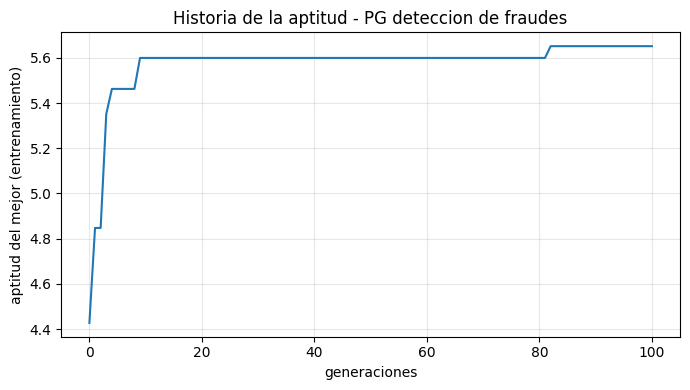

In [ ]:
# ---------------- PARAMETROS (editables) ----------------
N_TRANSACCIONES = 3000
SEMILLA         = 42
POBLACION       = 200
GENERACIONES    = 100
P_CRUCE         = 0.7
P_MUTACION      = 0.1
RUTA_CSV        = "transacciones.csv"
# --------------------------------------------------------

# --- datos
df = generar_datos(N_TRANSACCIONES, semilla=SEMILLA, ruta=RUTA_CSV)
print(f"Archivo '{RUTA_CSV}' generado con {len(df)} transacciones.")
print(f"Fraudes: {(df['fraude'] == 'si').sum()} ({(df['fraude'] == 'si').mean():.1%})")
display(df.head(10))
display(df.describe().round(1))

# --- particion estratificada 60 / 20 / 20
rng_np = np.random.default_rng(SEMILLA)
y_all = (df["fraude"] == "si").to_numpy()
idx_tr, idx_va, idx_te = [], [], []
for clase in (True, False):
    idx = rng_np.permutation(np.where(y_all == clase)[0])
    a, b = int(0.6 * len(idx)), int(0.8 * len(idx))
    idx_tr += list(idx[:a]); idx_va += list(idx[a:b]); idx_te += list(idx[b:])
tr, va, te = df.iloc[idx_tr], df.iloc[idx_va], df.iloc[idx_te]

Xtr, escalas = preparar_variables(tr)
Xva, _ = preparar_variables(va, escalas)
Xte, _ = preparar_variables(te, escalas)
ytr, yva, yte = (d["fraude"].eq("si").to_numpy() for d in (tr, va, te))

# --- evolucion
print("\n=== Evolucion ===")
mejor, historia = evolucionar(Xtr, ytr, Xva, yva, tam_pob=POBLACION,
                              generaciones=GENERACIONES, p_cruce=P_CRUCE,
                              p_mut=P_MUTACION, semilla=SEMILLA)

# --- resultados
print("\n=== MEJOR MODELO ENCONTRADO ===")
print("Regla:  salida = ", a_texto(mejor))
print("        si salida > 0  ->  POSIBLE FRAUDE")
print(f"Nodos: {cuenta_nodos(mejor)} | Profundidad: {profundidad(mejor)}")
print(f"Escalas: monto/{escalas['monto']:.0f}, distancia/{escalas['dist']:.2f}, "
      f"ingreso/{escalas['ingreso']:.0f}, hora*2*pi/24")
imprimir_metricas("Entrenamiento", metricas(mejor, Xtr, ytr))
imprimir_metricas("Validacion", metricas(mejor, Xva, yva))
imprimir_metricas("PRUEBA (datos nunca vistos)", metricas(mejor, Xte, yte))

# --- grafica de la aptitud
plt.figure(figsize=(7, 4))
plt.plot(historia)
plt.xlabel("generaciones"); plt.ylabel("aptitud del mejor (entrenamiento)")
plt.title("Historia de la aptitud - PG deteccion de fraudes")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 9. Probar el modelo con una transacción nueva

In [ ]:
nueva = pd.DataFrame([{
    "monto_pesos": 2_500_000,
    "hora_dia": 3.0,
    "distancia_residencia_km": 120.0,
    "ingreso_mensual": 2_800_000,
}])
Xn, _ = preparar_variables(nueva, escalas)
print("Resultado:", "POSIBLE FRAUDE" if predecir(mejor, Xn)[0] else "transaccion normal")

Resultado: POSIBLE FRAUDE


## 10. (Opcional) Descargar archivos a tu computador

In [ ]:
try:
    from google.colab import files
    with open("modelo_fraude.txt", "w", encoding="utf-8") as f:
        f.write(f"salida = {a_texto(mejor)}\nsi salida > 0 -> fraude\nescalas = {escalas}\n")
    files.download(RUTA_CSV)
    files.download("modelo_fraude.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>